# Benchmark error analysis

Companion to the Streamlit viewer. Streamlit shows aggregates; this notebook is for **reading individual posts** where the model gets it wrong.

Run order:
1. `benchmark embed && benchmark run configs/<file>.yaml && benchmark report` (in `apps/benchmark/`)
2. Open this notebook and Restart & Run All

Each section after Setup is independent — pick the ones you need.

## 0. Setup

Loads `summary.parquet` plus every per-experiment parquet into a `runs` dict. Sets `DATA_PATH` and `chosen_experiment` — change `chosen_experiment` to drill into a different run.

In [1]:
import sys
from pathlib import Path

NOTEBOOK = Path.cwd()
APP_DIR = NOTEBOOK.parent if NOTEBOOK.name == "notebooks" else NOTEBOOK
LLM_DIR = APP_DIR.parent / "llm"
for p in (str(APP_DIR), str(LLM_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import plotly.express as px

RESULTS_DIR = APP_DIR / "results"
DATA_PATH = APP_DIR / "data" / "control.jsonl"

summary_path = RESULTS_DIR / "summary.parquet"
if not summary_path.exists():
    print(f"no summary at {summary_path} - run `benchmark report` first")
    summary = pd.DataFrame()
    runs: dict[str, pd.DataFrame] = {}
else:
    summary = pd.read_parquet(summary_path)
    runs = {
        p.stem: pd.read_parquet(p)
        for p in sorted(RESULTS_DIR.glob("*.parquet"))
        if p.name != "summary.parquet"
    }
    print(f"loaded {len(summary)} experiments, {len(runs)} per-experiment parquets")

# Default drill-down target. Change this to inspect a different experiment.
chosen_experiment = next(iter(runs)) if runs else None
print(f"chosen_experiment = {chosen_experiment!r}")

summary

loaded 9 experiments, 9 per-experiment parquets
chosen_experiment = 'gpt-oss-120b-few-shot'


,experiment_id,n,n_errors,n_predicted,score_mae,score_rmse,score_mean_error,score_pearson_r,emotion_accuracy,emotion_macro_f1,aspect_accuracy,aspect_macro_f1,total_tokens,prompt_tokens_total,completion_tokens_total,mean_tokens,tokens_p50,tokens_p95,latency_ms_p50,latency_ms_p95
0,gpt-oss-120b-few-shot,400,0,282,0.386525,0.592506,-0.099291,0.886318,0.549645,0.464906,0.890071,0.467723,775552,722143,53409,1938.8800,1931.5,2053.20,1926.831542,3081.869379
1,gpt-oss-120b-retrieved-fewshot,400,0,343,0.441691,0.630262,-0.033528,0.865859,0.553936,0.496324,0.906706,0.482383,773371,705204,68167,1933.4275,1928.0,2105.25,4413.934833,7647.176093
2,gpt-oss-120b-zero-shot,400,0,317,0.432177,0.645294,-0.056782,0.864564,0.526814,0.470976,0.854890,0.424886,690437,568943,121494,1726.0925,1714.0,1914.10,3410.770104,12165.775411
3,llama-3.3-70b-retrieved-fewshot,400,0,396,0.397727,0.609790,0.165404,0.892058,0.626263,0.528438,0.896465,0.470817,563909,548499,15410,1409.7725,1404.0,1545.25,4171.092583,8134.143108
4,llama3.3-70b-few-shot,400,0,397,0.405542,0.623834,0.178841,0.892399,0.627204,0.519233,0.861461,0.427977,581481,566100,15381,1453.7025,1438.0,1550.00,858.876313,1275.933504
5,llama3.3-70b-zero-shot,400,0,394,0.463198,0.665025,0.059645,0.880118,0.571066,0.482002,0.868020,0.440191,426203,411300,14903,1065.5075,1050.0,1162.05,853.450271,1421.079579
6,qwen2.5-72b-instruct-fewshot-static,400,0,388,0.356959,0.500644,0.179124,0.915084,0.497423,0.378734,0.891753,0.446190,581778,563911,17867,1454.4450,1438.0,1548.20,2029.299646,2337.865093
7,qwen2.5-72b-instruct-retrieved-fewshot,400,0,392,0.355867,0.523065,0.085459,0.895239,0.479592,0.380996,0.887755,0.443422,560215,542308,17907,1400.5375,1395.0,1540.15,4672.504937,7682.547744
8,qwen2.5-72b-instruct-zero-shot,400,0,361,0.367036,0.524338,0.098338,0.900238,0.470914,0.370225,0.847645,0.427086,420580,402711,17869,1051.4500,1035.0,1144.30,1980.111250,2335.606213


In [2]:
# Helper: attach the original post text to a results frame so we can read what we got wrong.
def attach_text(df: pd.DataFrame) -> pd.DataFrame:
    if not DATA_PATH.exists():
        return df
    ds = pd.read_json(DATA_PATH, lines=True)[["post_id", "text"]]
    return df.merge(ds, on="post_id", how="left")

def relevant_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df["pred_relevant"] == True) & df["error"].isna()]

# Sanity: how many predictions and errors per experiment?
if runs:
    health = pd.DataFrame([
        {
            "experiment_id": eid,
            "n": len(df),
            "n_predicted": int(len(relevant_rows(df))),
            "n_errors": int(df["error"].notna().sum()),
            "n_irrelevant": int((df["pred_relevant"] == False).sum()),
        }
        for eid, df in runs.items()
    ])
    display(health)

,experiment_id,n,n_predicted,n_errors,n_irrelevant
0,gpt-oss-120b-few-shot,400,282,0,118
1,gpt-oss-120b-retrieved-fewshot,400,343,0,57
2,gpt-oss-120b-zero-shot,400,317,0,83
3,llama-3.3-70b-retrieved-fewshot,400,396,0,4
4,llama3.3-70b-few-shot,400,397,0,3
5,llama3.3-70b-zero-shot,400,394,0,6
6,qwen2.5-72b-instruct-fewshot-static,400,388,0,12
7,qwen2.5-72b-instruct-retrieved-fewshot,400,392,0,8
8,qwen2.5-72b-instruct-zero-shot,400,361,0,39


## 1. Score-regression error analysis

Signed-error histogram (positive = model overshoots), then the worst N misses with the actual post text.

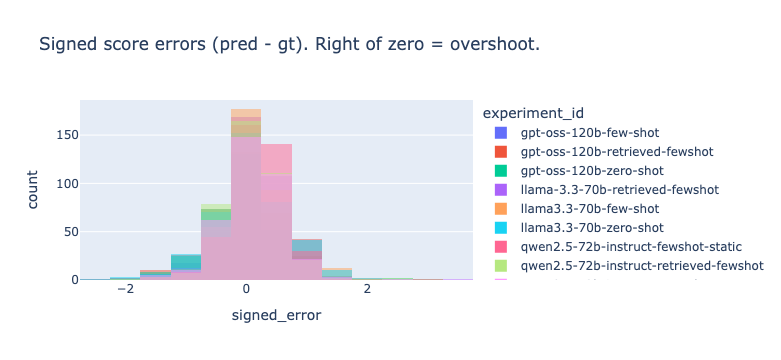

In [3]:
rows = []
for eid, df in runs.items():
    rel = relevant_rows(df).dropna(subset=["pred_score"])
    rows.extend(
        {"experiment_id": eid, "signed_error": float(p - g)}
        for p, g in zip(rel["pred_score"], rel["gt_score"])
    )
err_df = pd.DataFrame(rows)
if err_df.empty:
    print("no scored predictions yet")
else:
    fig = px.histogram(
        err_df, x="signed_error", color="experiment_id",
        barmode="overlay", nbins=30,
        title="Signed score errors (pred - gt). Right of zero = overshoot.",
    )
    fig.show()

In [4]:
from benchmark.metrics.regression import regression_report

N_WORST = 10
if chosen_experiment:
    df = runs[chosen_experiment]
    rel = attach_text(relevant_rows(df).dropna(subset=["pred_score"]).copy())
    rel["abs_err"] = (rel["pred_score"] - rel["gt_score"]).abs()

    rep = regression_report(rel["gt_score"], rel["pred_score"])
    print(f"{chosen_experiment}: MAE={rep.mae:.3f} RMSE={rep.rmse:.3f} "
          f"mean_error={rep.mean_error:+.3f} pearson_r={rep.pearson_r:.3f}")
    cols = [c for c in ["post_id", "text", "gt_score", "pred_score", "abs_err"] if c in rel.columns]
    display(rel.nlargest(N_WORST, "abs_err")[cols])

gpt-oss-120b-few-shot: MAE=0.387 RMSE=0.593 mean_error=-0.099 pearson_r=0.886


,post_id,text,gt_score,pred_score,abs_err
132,183,I love my Air and will probably never go back ...,4.5,2.0,2.5
185,264,"‚Äö√Ñ√∫Here we have five iPhones, Together the...",1.5,4.0,2.5
17,22,If you tell me clawdbot can do my taxes I‚Äôm ...,3.5,1.5,2.0
82,93,I do wonder if MS ever had a meeting the last ...,3.5,1.5,2.0
2,10,Why did Apple Music take off Dollar Menu 4 alb...,1.0,2.5,1.5
30,35,My M4 macbook pro just turned on its fans for ...,3.5,2.0,1.5
92,115,"Pfft, [Windows did this 30 years ago](https://...",3.0,1.5,1.5
240,351,'the iPhone was not the first example of its k...,3.5,2.0,1.5
241,355,I'm going against the hive on this one. I get ...,2.5,1.0,1.5
246,364,I'm quite happy Apple is bad at AI and I can j...,3.0,4.5,1.5


## 2. Emotion confusion drill-down

Read the actual posts where the model got the emotion wrong. Look for systematic patterns (e.g. SADNESS classified as ANGER on customer-service complaints).

In [5]:
if chosen_experiment:
    df = runs[chosen_experiment]
    rel = attach_text(relevant_rows(df).dropna(subset=["pred_emotion"]).copy())
    wrong = rel[rel["pred_emotion"] != rel["gt_emotion"]]
    print(f"{len(wrong)}/{len(rel)} emotion mistakes in {chosen_experiment}")
    cols = [c for c in ["post_id", "text", "gt_emotion", "pred_emotion", "gt_score", "pred_score"] if c in wrong.columns]
    display(wrong[cols].head(30))

127/282 emotion mistakes in gpt-oss-120b-few-shot


,post_id,text,gt_emotion,pred_emotion,gt_score,pred_score
2,10,Why did Apple Music take off Dollar Menu 4 alb...,ANGER,NEUTRAL,1.0,2.5
3,11,Alright @Apple_x000D_\n if y‚Äôall don‚Äôt rel...,FEAR,SADNESS,2.0,1.5
5,5,Yeah that is exactly the point... Samsung impr...,DISGUST,SADNESS,1.0,2.0
6,3,Apple does everything but allow us to turn off...,DISGUST,ANGER,1.5,1.5
10,14,They gotta feed their streaming service and Ap...,DISGUST,ANGER,2.0,2.0
12,18,"Got all set to draw, iPad charged, references ...",SADNESS,ANGER,2.0,1.5
15,20,"The iPhone upgrade is awful, disgusting. I hat...",ANGER,DISGUST,0.0,0.5
17,22,If you tell me clawdbot can do my taxes I‚Äôm ...,JOY,ANGER,3.5,1.5
21,23,Apple literally forcing me to upgrade my os. P...,DISGUST,ANGER,1.5,1.0
24,29,Apple won‚Äôt tell you but the iPad is the per...,SURPRISE,JOY,3.5,3.0


## 3. Aspect mismatch (raw vs normalized)

When the model's raw aspect output isn't in our taxonomy, `metrics/aspect.py::_SYNONYMS` maps it (e.g. "shipping" → DELIVERY). Mistakes here come in two flavors:

- The model is genuinely wrong (raw and normalized both don't match GT).
- Synonym map is incomplete — extend `_SYNONYMS` if you see common phrasings landing in OTHER.

In [ ]:
if chosen_experiment:
    df = runs[chosen_experiment]
    rel = attach_text(relevant_rows(df).dropna(subset=["pred_aspect_normalized"]).copy())
    wrong = rel[rel["pred_aspect_normalized"] != rel["gt_aspect"]]
    print(f"{len(wrong)}/{len(rel)} aspect mistakes (after normalization)")
    cols = [c for c in ["post_id", "text", "gt_aspect", "pred_aspect_raw", "pred_aspect_normalized"] if c in wrong.columns]
    display(wrong[cols].head(30))

    # Which raw outputs land in OTHER? Candidates for the synonym map.
    from benchmark.metrics.aspect import OTHER
    in_other = rel[rel["pred_aspect_normalized"] == OTHER]
    if not in_other.empty:
        print(f"\nraw outputs landing in OTHER ({len(in_other)} rows) - candidates for _SYNONYMS:")
        display(in_other["pred_aspect_raw"].value_counts().head(15))

## 4. Retrieved-exemplar inspection

For few-shot-retrieved experiments, read the exemplars the embedder picked. The failure mode you're hunting for: high lexical overlap but wrong sentiment (e.g. retrieves "loved this product" for a sarcastic "oh I just LOVED waiting on hold").

In [11]:
def has_fewshot(df: pd.DataFrame) -> bool:
    if "fewshot_post_ids" not in df.columns:
        return False
    return df["fewshot_post_ids"].apply(lambda x: len(x) > 0 if x is not None else False).any()

def _load_lookup_ds() -> pd.DataFrame:
    """Combine eval + held-out exemplar datasets so retrieved IDs (10000+) resolve."""
    frames = [pd.read_json(DATA_PATH, lines=True)]
    exemplar_path = APP_DIR / "data" / "apple_fewshot_dataset.jsonl"
    if exemplar_path.exists():
        frames.append(pd.read_json(exemplar_path, lines=True))
    return pd.concat(frames, ignore_index=True).drop_duplicates("post_id").set_index("post_id")

fewshot_runs = {eid: df for eid, df in runs.items() if has_fewshot(df)}
if not fewshot_runs:
    print("no few-shot retrieved runs found - this section is a no-op")
elif not DATA_PATH.exists():
    print(f"need {DATA_PATH} to look up exemplar text")
else:
    fs_eid = next(iter(fewshot_runs))
    df = fewshot_runs[fs_eid]
    rel = relevant_rows(df)
    if rel.empty:
        print("no relevant rows in this experiment")
    else:
        # Pick the worst score-miss in this experiment - that's where retrieval
        # quality matters most.
        rel = rel.dropna(subset=["pred_score"]).copy()
        rel["abs_err"] = (rel["pred_score"] - rel["gt_score"]).abs()
        target = rel.nlargest(1, "abs_err").iloc[0]
        ds = _load_lookup_ds()

        print(f"=== experiment {fs_eid}, post {int(target['post_id'])} ===")
        print(f"text: {ds.loc[target['post_id'], 'text']}")
        print(f"gt:   score={ds.loc[target['post_id'], 'gt_score']} "
              f"emotion={ds.loc[target['post_id'], 'gt_emotion']} "
              f"aspect={ds.loc[target['post_id'], 'gt_aspect']}")
        print(f"pred: score={target['pred_score']} "
              f"emotion={target['pred_emotion']} "
              f"aspect={target['pred_aspect_normalized']}")
        print("\nretrieved exemplars (in rank order):")
        for ex_id in target["fewshot_post_ids"]:
            ex_id = int(ex_id)
            if ex_id not in ds.index:
                print(f"  [{ex_id}] <not found in eval or exemplar dataset>")
                continue
            ex = ds.loc[ex_id]
            print(f"  [{ex_id}] {ex['text']!r}")
            print(f"        gt: score={ex['gt_score']} emotion={ex['gt_emotion']} aspect={ex['gt_aspect']}")

=== experiment gpt-oss-120b-few-shot, post 183 ===
text: I love my Air and will probably never go back to a Pro model. Way too heavy and bulky.
gt:   score=4.5 emotion=JOY aspect=PRODUCT
pred: score=2.0 emotion=DISGUST aspect=PRODUCT

retrieved exemplars (in rank order):
  [10065] 'I love this liquid glass design!'
        gt: score=5.0 emotion=JOY aspect=PRODUCT
  [10033] 'Is an Iphone air a good deal at 850 USD?'
        gt: score=2.5 emotion=NEUTRAL aspect=PRICING
  [10025] 'This is why I ordered my M5 Max MBP as soon as I could. Between the RAM shortage, tariffs, and increasing world instability and inflation, I thought I better get it while I could, and while I can afford to......'
        gt: score=2.0 emotion=FEAR aspect=PRICING
  [10028] 'Good because as a 17 pro owner I kinda regret not getting the air‚Äö√Ñ¬∂'
        gt: score=2.0 emotion=SADNESS aspect=PRODUCT
  [10005] 'Another garbage megacorp trying to fight workers rights'
        gt: score=0.5 emotion=ANGER aspect=BRAND

## 5. Per-fold breakdown

If one fold is markedly worse than the others, suspect either dataset imbalance or a bug in the leakage masking. Both worth knowing before paper claims.

,experiment_id,fold,n,score_mae,emotion_accuracy
0,gpt-oss-120b-few-shot,0,46,0.369565,0.586957
1,gpt-oss-120b-few-shot,1,64,0.406250,0.500000
2,gpt-oss-120b-few-shot,2,62,0.338710,0.580645
3,gpt-oss-120b-few-shot,3,60,0.350000,0.550000
4,gpt-oss-120b-few-shot,4,50,0.480000,0.540000
5,gpt-oss-120b-retrieved-fewshot,0,64,0.460938,0.578125
6,gpt-oss-120b-retrieved-fewshot,1,77,0.441558,0.493506
7,gpt-oss-120b-retrieved-fewshot,2,71,0.394366,0.633803
8,gpt-oss-120b-retrieved-fewshot,3,70,0.400000,0.471429
9,gpt-oss-120b-retrieved-fewshot,4,61,0.524590,0.606557


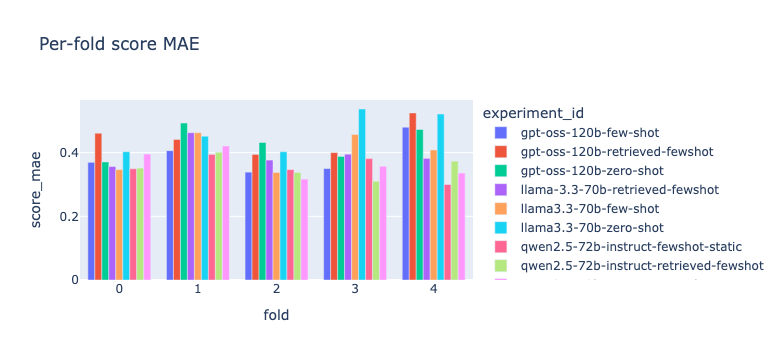

In [7]:
rows = []
for eid, df in runs.items():
    rel = relevant_rows(df).dropna(subset=["pred_score"])
    for fold, sub in rel.groupby("fold"):
        if sub.empty:
            continue
        rep = regression_report(sub["gt_score"], sub["pred_score"])
        emo_acc = (
            float((sub["pred_emotion"] == sub["gt_emotion"]).mean())
            if "pred_emotion" in sub.columns else float("nan")
        )
        rows.append({
            "experiment_id": eid,
            "fold": int(fold),
            "n": len(sub),
            "score_mae": rep.mae,
            "emotion_accuracy": emo_acc,
        })
fold_df = pd.DataFrame(rows)
if fold_df.empty:
    print("no per-fold data")
else:
    display(fold_df.sort_values(["experiment_id", "fold"]).reset_index(drop=True))
    fig = px.bar(
        fold_df, x="fold", y="score_mae", color="experiment_id",
        barmode="group", title="Per-fold score MAE",
    )
    fig.show()

## 6. Pairwise disagreement browser

Pick two experiments, read the rows where they disagree. The Streamlit viewer gives you significance numbers; this gives you the actual posts so you can write qualitative observations for the paper.

In [8]:
exp_ids = list(runs)
if len(exp_ids) < 2:
    print(f"need >= 2 experiments, have {len(exp_ids)}")
else:
    a, b = exp_ids[0], exp_ids[1]  # change to compare different pairs
    da, db = runs[a], runs[b]
    merged = da.merge(db, on="post_id", suffixes=("_a", "_b"))
    merged = merged[
        (merged["pred_relevant_a"] == True) & (merged["pred_relevant_b"] == True)
        & merged["error_a"].isna() & merged["error_b"].isna()
    ]
    merged = attach_text(merged) if "text" not in merged.columns else merged
    disagree = merged[
        (merged["pred_emotion_a"] != merged["pred_emotion_b"])
        | (merged["pred_aspect_normalized_a"] != merged["pred_aspect_normalized_b"])
    ]
    print(f"{a} vs {b}: {len(disagree)}/{len(merged)} posts disagree")
    cols = [c for c in [
        "post_id", "text",
        "gt_emotion_a", "pred_emotion_a", "pred_emotion_b",
        "gt_aspect_a", "pred_aspect_normalized_a", "pred_aspect_normalized_b",
        "gt_score_a", "pred_score_a", "pred_score_b",
    ] if c in disagree.columns]
    display(disagree[cols].head(20))

gpt-oss-120b-few-shot vs gpt-oss-120b-retrieved-fewshot: 108/278 posts disagree


,post_id,text,gt_emotion_a,pred_emotion_a,pred_emotion_b,gt_aspect_a,pred_aspect_normalized_a,pred_aspect_normalized_b,gt_score_a,pred_score_a,pred_score_b
4,1,Apple musics karaoke feature is everything,JOY,JOY,JOY,PRODUCT,PRODUCT,SERVICE,4.5,5.0,5.0
5,5,Yeah that is exactly the point... Samsung impr...,DISGUST,SADNESS,ANGER,BRAND,BRAND,BRAND,1.0,2.0,1.0
6,3,Apple does everything but allow us to turn off...,DISGUST,ANGER,SADNESS,PRODUCT,PRODUCT,PRODUCT,1.5,1.5,1.5
8,12,Amen! Apple‚Äôs new iPhone 17 Pro camera ad is...,JOY,JOY,JOY,PRODUCT,BRAND,PRODUCT,5.0,5.0,5.0
9,13,How the fuck did Apple approve those screensho...,ANGER,ANGER,ANGER,SERVICE,SERVICE,BRAND,1.5,1.0,1.5
10,14,They gotta feed their streaming service and Ap...,DISGUST,ANGER,ANGER,BRAND,PRODUCT,BRAND,2.0,2.0,2.0
17,22,If you tell me clawdbot can do my taxes I‚Äôm ...,JOY,ANGER,ANGER,PRODUCT,BRAND,PRODUCT,3.5,1.5,3.0
19,26,Apple TV shows are just gems waiting to be dis...,JOY,JOY,JOY,PRODUCT,PRODUCT,SERVICE,4.0,4.5,4.0
30,35,My M4 macbook pro just turned on its fans for ...,SURPRISE,SADNESS,SURPRISE,PRODUCT,PRODUCT,PRODUCT,3.5,2.0,2.5
31,31,"If Steve Jobs were alive, Apple Intelligence w...",DISGUST,ANGER,ANGER,PRODUCT,BRAND,PRODUCT,2.0,1.5,1.5


## 7. Latency distribution

Cost story isn't just MAE. Once paid RunPod runs start, p95 latency is part of the comparison.

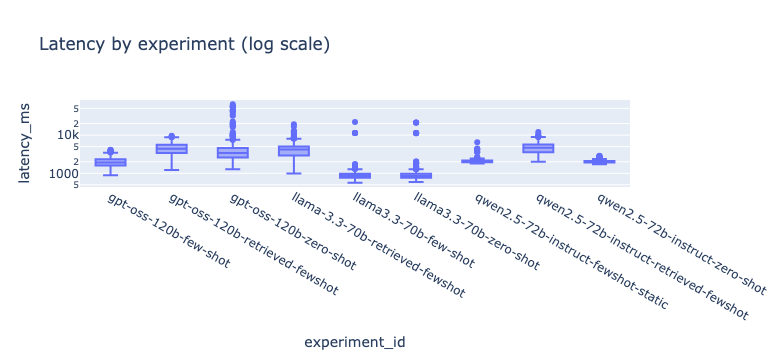

,count,mean,std,min,50%,90%,95%,99%,max
experiment_id,,,,,,,,,
gpt-oss-120b-few-shot,400.0,2007.982961,562.188074,887.352000,1926.831542,2687.286026,3081.869379,3820.652652,4134.662666
gpt-oss-120b-retrieved-fewshot,400.0,4569.850668,1654.347355,1214.821000,4413.934833,6913.852212,7647.176093,8853.183936,9606.396500
gpt-oss-120b-zero-shot,400.0,5305.688811,8016.937858,1273.418709,3410.770104,6527.833850,12165.775411,54050.014999,63673.429167
llama-3.3-70b-retrieved-fewshot,400.0,4352.450808,2171.721979,990.243375,4171.092583,6959.516446,8134.143108,12339.848347,19118.212542
llama3.3-70b-few-shot,400.0,1045.271930,1486.972147,569.614750,858.876313,1158.172117,1275.933504,11254.492530,21935.635042
llama3.3-70b-zero-shot,400.0,1204.309827,2159.962618,592.461292,853.450271,1171.166654,1421.079579,11288.025441,21314.182417
qwen2.5-72b-instruct-fewshot-static,400.0,2104.297959,366.920970,1806.000666,2029.299646,2280.524000,2337.865093,4216.503865,6473.239709
qwen2.5-72b-instruct-retrieved-fewshot,400.0,4773.535645,1601.977081,2008.766708,4672.504937,6699.739458,7682.547744,9049.574996,11953.283833
qwen2.5-72b-instruct-zero-shot,400.0,2026.725588,175.876020,1728.495584,1980.111250,2249.860150,2335.606213,2708.016607,2875.505000


In [12]:
frames = []
for eid, df in runs.items():
    sub = df[df["latency_ms"].notna()][["latency_ms"]].copy()
    sub["experiment_id"] = eid
    frames.append(sub)
if not frames:
    print("no latency data (cached results don't re-time)")
else:
    lat_df = pd.concat(frames, ignore_index=True)
    fig = px.box(
        lat_df, x="experiment_id", y="latency_ms",
        points="outliers", title="Latency by experiment (log scale)",
    )
    fig.update_yaxes(type="log")
    fig.show()
    display(lat_df.groupby("experiment_id")["latency_ms"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))